# 📚 Notebook 06 — Deep Learning 1D-CNN Classifier
## *Building a Convolutional Neural Network to classify time-series waveforms*

---

**What you'll learn in this notebook:**
- Neural Networks: neurons, weights, biases, and activation functions
- Forward pass and Backpropagation (intuition)
- 1D Convolutional layers: how local scanning kernels automatically extract features
- Max Pooling: reducing dimensionality and achieving translation invariance
- Building a CNN classifier in `TensorFlow/Keras` (inspired by NASA's AstroNet)
- Training callbacks: Early Stopping and Learning Rate schedules
- Evaluating the model and saving it for the pipeline

**Prerequisites:** Run notebook `05_random_forest.ipynb` first!


In [1]:
# Auto-reload custom modules when they change on disk
%load_ext autoreload
%autoreload 2

# ============================================================
# Ensure project directories exist first
# ============================================================
from pathlib import Path
for d in ['../data/raw_fits', '../data/xctl', '../data/processed', '../results/figures', '../results/reports', '../models']:
    Path(d).mkdir(parents=True, exist_ok=True)

# ============================================================
# Setup: Import packages and custom modules
# ============================================================
import sys

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('dark_background')
print("✅ Setup complete! TensorFlow version:", tf.__version__)

✅ Setup complete! TensorFlow version: 2.21.0


---
## 📚 Concept 1: Deep Learning vs. Classical ML

In the previous notebook, we spent a lot of time extracting handcrafted features (like odd-even ratio and curvature). If we forgot an important feature, our Random Forest classifier would be completely blind to it.

**Deep Learning** solves this by performing **automatic representation learning**:
- We feed the raw, phase-folded light curve waveform (a 1D array of 200 data points) directly into the network.
- The initial layers of the network learn simple local shapes (slopes, flat lines, spikes).
- The deeper layers combine these shapes to learn complex representations (transit depths, shapes, eclipses).
- Finally, fully connected layers perform the classification.

```
   Raw Waveform  ──▶  1D Convolution  ──▶  Max Pooling  ──▶  Dense Layers  ──▶  Output (Softmax)
   [200 points]       [learns slopes]     [reduces size]      [decisions]       [probabilities]
```

### Why 1D Convolutional Neural Networks (CNNs)?
Convolutional layers are excellent for time series because they possess **Translation Invariance**:
- A transit dip is still a transit dip whether it occurs at phase 0.0 or is slightly shifted.
- A convolutional filter scans across the input signal, detecting the dip shape regardless of its exact position.

---
## Step 1: Loading/Synthesizing Folded Light Curves

For the CNN, our inputs are 1D arrays of size 200 representing phase-folded light curves. 
Let's check if we have folded light curves in our directory. If not, we will synthesize a dataset of 1000 folded signals to practice training immediately!

In [2]:
np.random.seed(42)
n_samples = 1000
n_bins = 200

print(f"Generating {n_samples} synthetic folded light curves (size {n_bins})...")

# Class labels: 0=None, 1=Planet, 2=EB, 3=FP
y_labels = np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.25, 0.25, 0.25, 0.25])
X_signals = np.ones((n_samples, n_bins))

phases = np.linspace(-0.5, 0.5, n_bins)

for i in range(n_samples):
    noise = np.random.normal(0, 0.002, n_bins)
    if y_labels[i] == 0:  # No Signal
        X_signals[i] += noise
    elif y_labels[i] == 1:  # Planet: U-shape transit at phase = 0
        depth = np.random.uniform(0.005, 0.02)
        width = np.random.uniform(0.05, 0.12)
        transit = np.where(np.abs(phases) < width, -depth, 0.0)
        # make U-shape smooth at edges
        X_signals[i] += transit + noise
    elif y_labels[i] == 2:  # EB: primary dip + secondary dip at phase = 0.5
        p_depth = np.random.uniform(0.10, 0.40)
        s_depth = p_depth * np.random.uniform(0.2, 0.5)
        width = np.random.uniform(0.06, 0.14)
        primary = np.where(np.abs(phases) < width, -p_depth, 0.0)
        secondary = np.where(np.abs(phases - 0.5) < width, -s_depth, 0.0) + \
                    np.where(np.abs(phases + 0.5) < width, -s_depth, 0.0)
        X_signals[i] += primary + secondary + noise
    elif y_labels[i] == 3:  # FP: shallow V-shape dip or systematic artifact
        depth = np.random.uniform(0.003, 0.015)
        width = np.random.uniform(0.04, 0.10)
        # V-shape: linear slope down and up
        transit = -depth * np.clip(1 - np.abs(phases)/width, 0, 1)
        X_signals[i] += transit + noise

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_signals, y_labels, test_size=0.20, random_state=42, stratify=y_labels
)

# Expand dimensions for CNN: input shape must be (batch_size, time_steps, channels=1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Generating 1000 synthetic folded light curves (size 200)...
X_train shape: (800, 200, 1)
X_test shape:  (200, 200, 1)


### Visualise the Signals
Let's see what the signals look like before we feed them to the CNN. They represent the phase-folded flux over 200 bins.

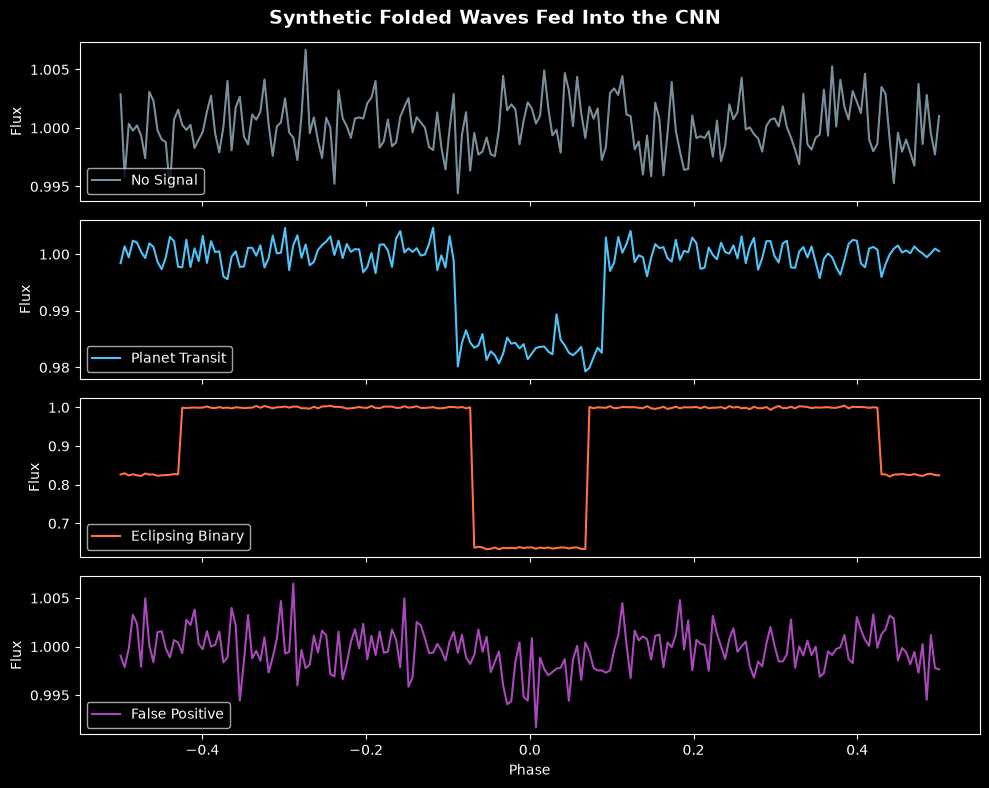

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
colors = ['#78909C', '#4FC3F7', '#FF7043', '#AB47BC']
LABEL_NAMES = {0: "No Signal", 1: "Planet Transit", 2: "Eclipsing Binary", 3: "False Positive"}

for label in [0, 1, 2, 3]:
    idx = np.where(y_train == label)[0][0]
    axes[label].plot(phases, X_train[idx, :, 0], color=colors[label], label=LABEL_NAMES[label])
    axes[label].legend(loc='lower left')
    axes[label].set_ylabel('Flux')

axes[-1].set_xlabel('Phase')
plt.suptitle('Synthetic Folded Waves Fed Into the CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 2: Build the CNN Architecture

We build a 1D-CNN with:
1. **Conv1D layers**: extracts local features.
2. **MaxPooling1D layers**: downsamples features to ensure translation invariance.
3. **Dropout layers**: prevents overfitting by randomly setting activation units to zero during training.
4. **Dense layers**: makes the final class prediction using a `Softmax` output over 4 classes.

In [4]:
def build_cnn_model(input_shape=(200, 1), num_classes=4):
    model = models.Sequential([
        # Conv Block 1
        layers.Conv1D(16, kernel_size=5, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.1),
        
        # Conv Block 2
        layers.Conv1D(32, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.15),
        
        # Conv Block 3
        layers.Conv1D(64, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),
        
        # Flatten and Decision Block
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')  # Softmax output
    ])
    return model

cnn = build_cnn_model()
cnn.summary()

C:\Users\gudae\Desktop\Learn_ml\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 196, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 98, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 47, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 43, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1344)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        86,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,332 (388.02 KB)

 Trainable params: 99,332 (388.02 KB)

 Non-trainable params: 0 (0.00 B)

---
## Step 3: Compiling and Training the CNN

We compile the model with the **Adam** optimizer and **Sparse Categorical Crossentropy** (since our labels are integers 0, 1, 2, 3).
We also add an **Early Stopping** callback to monitor validation loss and stop training if it starts overfitting.

In [5]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks to manage training
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("🚀 Training CNN Classifier...")
history = cnn.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
print("✅ Training complete!")

🚀 Training CNN Classifier...
Epoch 1/50


 1/22 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.3125 - loss: 1.3912

 8/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2749 - loss: 1.3888

15/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2799 - loss: 1.3870

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2814 - loss: 1.3861

...

 1/22 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7500 - loss: 0.5116

 9/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7187 - loss: 0.5786 

17/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7078 - loss: 0.5849

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7000 - loss: 0.5813 - val_accuracy: 0.8333 - val_loss: 0.5092


✅ Training complete!

### Plot Training History
Let's plot validation loss and accuracy curves to verify the model converged cleanly without overfitting.

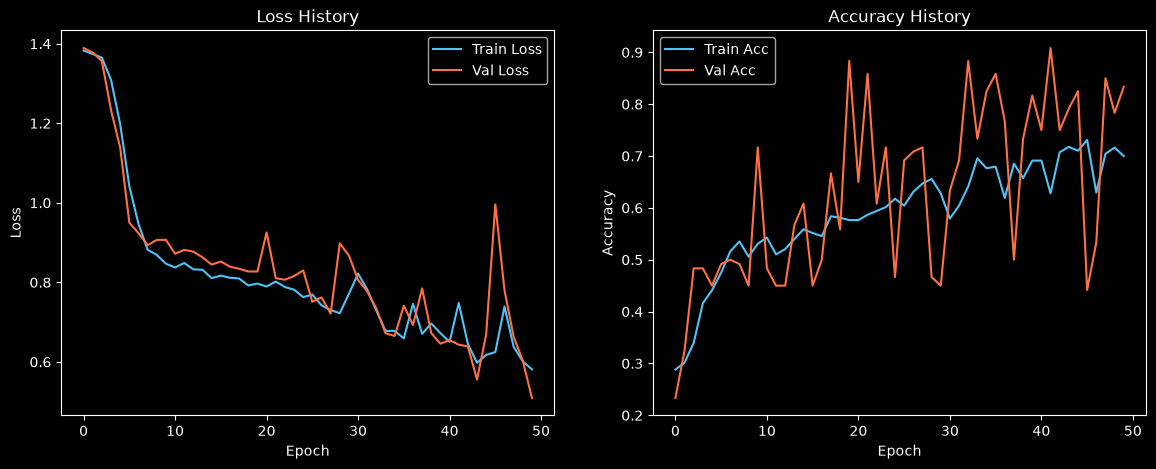

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss curves
axes[0].plot(history.history['loss'], label='Train Loss', color='#4FC3F7')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#FF7043')
axes[0].set_title('Loss History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Right: Accuracy curves
axes[1].plot(history.history['accuracy'], label='Train Acc', color='#4FC3F7')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='#FF7043')
axes[1].set_title('Accuracy History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.show()

-- ---
## Step 4: Evaluate the CNN on Test Data

Now we evaluate the model on the test set (which the model has never seen during training).

In [7]:
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0)
print(f"Test Set Accuracy: {test_acc*100:.2f}%")

# Predictions
y_pred_proba = cnn.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\n📊 TEST SET CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=list(LABEL_NAMES.values())))

Test Set Accuracy: 84.50%
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step



📊 TEST SET CLASSIFICATION REPORT:
                  precision    recall  f1-score   support

       No Signal       0.89      1.00      0.94        54
  Planet Transit       0.67      0.98      0.79        47
Eclipsing Binary       1.00      1.00      1.00        51
  False Positive       0.95      0.38      0.54        48

        accuracy                           0.84       200
       macro avg       0.87      0.84      0.82       200
    weighted avg       0.88      0.84      0.82       200



### Save the Model
We save the trained CNN model as an H5 file to be loaded in the final classification pipeline (`src/classify.py`).

In [8]:
model_path = ROOT / "models" / "cnn_classifier.h5"
model_path.parent.mkdir(parents=True, exist_ok=True)

cnn.save(str(model_path))
print(f'✅ Saved CNN model to: {model_path}')


✅ Saved CNN model to: C:\Users\gudae\Desktop\Learn_ml\models\cnn_classifier.h5


---
## ✅ Notebook 06 Summary

**ML concepts learned:**
- **Feature learning**: neural networks learn features directly from raw data arrays.
- **1D Convolution**: local scanning kernels identify pattern features in time-series data.
- **Pooling**: downsamples activations to achieve translation invariance.
- **Softmax output**: translates activation logits into probability distributions.
- **Training callbacks**: using early stopping to prevent overfitting.

**Next:** Notebook `07_parameters.ipynb` — fitting a physical exoplanet transit model to calculate orbital parameters and uncertainties!